# 🧱 Texture & Surface Feature Analysis for Mango Ripeness Assessment
### Course: BMDS2133 Image Processing | Assignment Mode A: Comparative & Enhancement Study
**Developer:** Wong Kai Bin (kb)  
**Module:** Texture & Surface Analysis (Mode A Comparative & Enhancement Framework)  
**Academic Requirement:** Implementation and benchmarking of 4 distinct classical image processing texture feature extraction algorithms, directional spatial sensitivity analysis, and an Enhanced Multi-Descriptor Hybrid Texture Pipeline.

---

### Overview of Mode A Framework:
1. **Multi-Algorithm Implementation (4 Baselines):**
   * **Baseline 1:** First-Order Statistical Intensity Moments (Histogram-based Texture)
   * **Baseline 2:** Spatial Texture Gradient & Surface Roughness Filtering (Sobel Spatial Frequency)
   * **Baseline 3:** Directional Gray Level Co-occurrence Matrix (GLCM Haralick Descriptors across 4 angles)
   * **Baseline 4:** Local Binary Patterns (Uniform Invariant LBP Micro-Structure)
2. **Directional & Spatial Sensitivity Study:** Quantitative ablation comparing individual GLCM orientations ($0^\circ, 45^\circ, 90^\circ, 135^\circ$) versus rotation-invariant averaging.
3. **Proposed Enhanced Hybrid Pipeline:** Multi-Descriptor Texture Fusion combining 2nd-order spatial co-occurrence (GLCM), invariant micro-topology (LBP), and spatial roughness gradients.
4. **Mode A Table 2.1 Comparative Benchmark:** Quantitative evaluation across all 4 baselines and the enhanced hybrid method.
5. **Prototype Integration & Serialization:** Exporting production-ready models and feature matrices to `output/texture_based/`.


## 1. [Configuration] Environment Setup & Parameters


In [ ]:
import os
import glob
import time
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

# Locate project directory robustly
NOTEBOOK_DIR = Path(os.getcwd())
if NOTEBOOK_DIR.name == 'notebooks':
    ROOT = NOTEBOOK_DIR.parent
else:
    ROOT = NOTEBOOK_DIR

DATASET_ROOT = ROOT / 'cleaned_data'
OUTPUT_DIR = ROOT / 'output' / 'texture_based'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ripeness classes & Label mapping
CLASSES = ['unripe', 'fully_ripe', 'overripe']
LABEL_MAP = {cls_name: i for i, cls_name in enumerate(CLASSES)}

# GLCM & LBP Hyperparameters
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_NAMES = ['0_deg', '45_deg', '90_deg', '135_deg']
LBP_P = 8
LBP_R = 1
LBP_METHOD = 'uniform'

print(f"[Configuration] Dataset root : {DATASET_ROOT}")
print(f"[Configuration] Output dir   : {OUTPUT_DIR}")
print(f"[Configuration] Classes      : {CLASSES}")


[Configuration] Dataset root : C:\repository\mango-ripeness-grading\cleaned_data
[Configuration] Output dir   : C:\repository\mango-ripeness-grading\output\texture_based
[Configuration] Classes      : ['unripe', 'fully_ripe', 'overripe']


## 2. [Dataset Inspection] Verification of Class Distributions
Verifying image counts across the standardized `cleaned_data` directory structure (Train & Test splits).


In [2]:
dataset_summary = []
for split in ['train', 'test']:
    for cls in CLASSES:
        folder = DATASET_ROOT / split / cls
        paths = list(folder.glob('*.*'))
        dataset_summary.append({
            'Split': split,
            'Ripeness Stage': cls,
            'Image Count': len(paths)
        })

df_summary = pd.DataFrame(dataset_summary)
print("[Dataset Inspection] Summary Distribution Table:")
display(df_summary)

total_train = df_summary[df_summary['Split'] == 'train']['Image Count'].sum()
total_test = df_summary[df_summary['Split'] == 'test']['Image Count'].sum()
print(f"Total Samples: {total_train + total_test} (Train: {total_train}, Test: {total_test})")


,Split,Ripeness Stage,Image Count
0,train,unripe,190
1,train,fully_ripe,189
2,train,overripe,192
3,test,unripe,48
4,test,fully_ripe,48
5,test,overripe,48


[Dataset Inspection] Summary Distribution Table:
Total Samples: 715 (Train: 571, Test: 144)


## 3. [Preprocessing] Fruit Mask Segmentation & ROI Isolation
Segmenting the foreground mango from pure black background pixels to prevent background zeros from distorting texture matrices.


In [3]:
def get_fruit_mask(img_bgr, thresh=20):
    """Extract and clean foreground mango mask from black background."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > thresh).astype(np.uint8) * 255
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, se)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, se)
    return mask

# Verify masking on a sample image
sample_img = cv2.imread(str(sorted((DATASET_ROOT / 'test' / 'fully_ripe').glob('*.jpg'))[0]))
sample_mask = get_fruit_mask(sample_img)
sample_gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)
sample_fruit_px = sample_gray[sample_mask > 0]

print(f"[Preprocessing] Sample dimensions: {sample_img.shape}")
print(f"[Preprocessing] Foreground fruit pixels: {len(sample_fruit_px):,} / {sample_img.shape[0]*sample_img.shape[1]:,}")


[Preprocessing] Sample dimensions: (640, 640, 3)
[Preprocessing] Foreground fruit pixels: 95,880 / 409,600


## 4. [Methodology] Formulation of 4 Distinct Baseline Image Processing Algorithms

Four classical image processing paradigms are formulated for surface texture characterization:

---

### Algorithm 1 (Baseline 1): First-Order Statistical Intensity Moments (Histogram-based)
Treats surface texture as global intensity probability density $P(g)$:
* **Mean ($\mu$):** Average brightness $\sum g P(g)$
* **Variance ($\sigma^2$):** Intensity spread $\sum (g - \mu)^2 P(g)$
* **Skewness ($S$):** Asymmetry of surface tone $\frac{1}{\sigma^3} \sum (g - \mu)^3 P(g)$
* **Kurtosis ($K$):** Peakedness / tail heaviness $\frac{1}{\sigma^4} \sum (g - \mu)^4 P(g)$
* **Entropy ($H$):** Information content $-\sum P(g) \log_2 P(g)$

---

### Algorithm 2 (Baseline 2): Spatial Texture Gradient & Surface Roughness (Sobel)
Quantifies tactile micro-roughness via spatial frequency convolution:
* **Gradient Magnitude:** $G(x,y) = \sqrt{G_x^2 + G_y^2}$
* **Surface Roughness Index:** Mean magnitude across fruit pixels $\mu_G$
* **Gradient Variance:** Spatial variance of gradient transitions $\sigma_G^2$
* **High-Gradient Area Ratio:** Percentage of exocarp exhibiting high spatial frequency ($G > 25$)
* **Laplacian Sharpness:** Variance of Laplacian $\nabla^2 I$

---

### Algorithm 3 (Baseline 3): Directional Gray Level Co-occurrence Matrix (GLCM Haralick)
Computes 2nd-order joint spatial distribution $P(i,j | d=1, \theta)$:
* **Contrast:** $\sum |i-j|^2 P(i,j)$ (local roughness)
* **Correlation:** Linear gray-level dependence
* **Energy / ASM:** $\sum P(i,j)^2$ (uniformity/smoothness)
* **Homogeneity / IDM:** $\sum \frac{P(i,j)}{1+|i-j|}$

---

### Algorithm 4 (Baseline 4): Local Binary Patterns (Uniform Invariant LBP)
Circularly symmetric micro-structure operator ($P=8, R=1$, uniform):
* **LBP Mean:** Average micro-pattern code
* **LBP Variance:** Micro-topological roughness
* **LBP Pattern Entropy:** Shannon entropy of uniform pattern histogram


In [ ]:
# Algorithm 1: First-Order
def run_alg1_first_order(gray, mask):
    """Extract 5 first-order statistical moments from fruit intensity histogram."""
    px = gray[mask > 0].astype(np.float64)
    if len(px) == 0:
        return {'fo_mean': 0.0, 'fo_var': 0.0, 'fo_skew': 0.0, 'fo_kurt': 0.0, 'fo_entropy': 0.0}
    
    counts, _ = np.histogram(px, bins=256, range=(0, 256), density=True)
    counts = counts[counts > 0]
    ent = -float(np.sum(counts * np.log2(counts)))
    
    return {
        'fo_mean': float(np.mean(px)),
        'fo_var': float(np.var(px)),
        'fo_skew': float(stats.skew(px)),
        'fo_kurt': float(stats.kurtosis(px)),
        'fo_entropy': ent
    }

# Algorithm 2: Sobel
def run_alg2_spatial_gradient(gray, mask):
    """Extract 4 spatial gradient and micro-roughness metrics."""
    denoised = cv2.medianBlur(gray, 3)
    sobel_x = cv2.Sobel(denoised, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(denoised, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)
    
    laplacian = cv2.Laplacian(denoised, cv2.CV_64F)
    
    fruit_grad = sobel[mask > 0]
    fruit_lap = laplacian[mask > 0]
    
    if len(fruit_grad) == 0:
        return {'grad_mean_roughness': 0.0, 'grad_variance': 0.0, 'grad_high_ratio': 0.0, 'laplacian_var': 0.0}, sobel
        
    high_grad_count = np.sum(fruit_grad > 25.0)
    high_grad_ratio = float(high_grad_count / len(fruit_grad) * 100.0)
    
    metrics = {
        'grad_mean_roughness': float(np.mean(fruit_grad)),
        'grad_variance': float(np.var(fruit_grad)),
        'grad_high_ratio': high_grad_ratio,
        'laplacian_var': float(np.var(fruit_lap))
    }
    return metrics, sobel

# Algorithm 3: Directional Gray Level Co-occurrence Matrix (GLCM)
def run_alg3_directional_glcm(gray, mask, angles=GLCM_ANGLES):
    """Extract 4 GLCM features (Contrast, Correlation, Energy, Homogeneity)."""
    masked_gray = cv2.bitwise_and(gray, gray, mask=mask)
    glcm = graycomatrix(masked_gray, distances=GLCM_DISTANCES,
                        angles=angles, levels=256,
                        symmetric=True, normed=False)
    # Zero-out background pairs at level 0
    glcm[0, :, :, :] = 0
    glcm[:, 0, :, :] = 0
    total = glcm.sum()
    if total > 0:
        glcm = glcm.astype(np.float64) / total

    return {
        'glcm_contrast': float(np.mean(graycoprops(glcm, 'contrast'))),
        'glcm_correlation': float(np.mean(graycoprops(glcm, 'correlation'))),
        'glcm_energy': float(np.mean(graycoprops(glcm, 'energy'))),
        'glcm_homogeneity': float(np.mean(graycoprops(glcm, 'homogeneity')))
    }, glcm

# Algorithm 4: Local Binary Patterns (LBP)
def run_alg4_lbp(gray, mask, P=LBP_P, R=LBP_R):
    """Extract 3 uniform LBP statistics (Mean, Variance, Shannon Entropy)."""
    lbp = local_binary_pattern(gray, P=P, R=R, method=LBP_METHOD)
    fruit_lbp = lbp[mask > 0]

    if len(fruit_lbp) == 0:
        return {'lbp_mean': 0.0, 'lbp_variance': 0.0, 'lbp_entropy': 0.0}, lbp

    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(fruit_lbp, bins=n_bins, range=(0, n_bins), density=True)
    hist = hist[hist > 0]
    entropy = -float(np.sum(hist * np.log2(hist)))

    metrics = {
        'lbp_mean': float(np.mean(fruit_lbp)),
        'lbp_variance': float(np.var(fruit_lbp)),
        'lbp_entropy': entropy
    }
    return metrics, lbp


## 5. [Visualization] Visual Comparison Across the 4 Texture Baselines
Visualizing intermediate transformations for representative samples from each ripeness stage (`unripe`, `fully_ripe`, `overripe`) across all 4 baseline techniques.


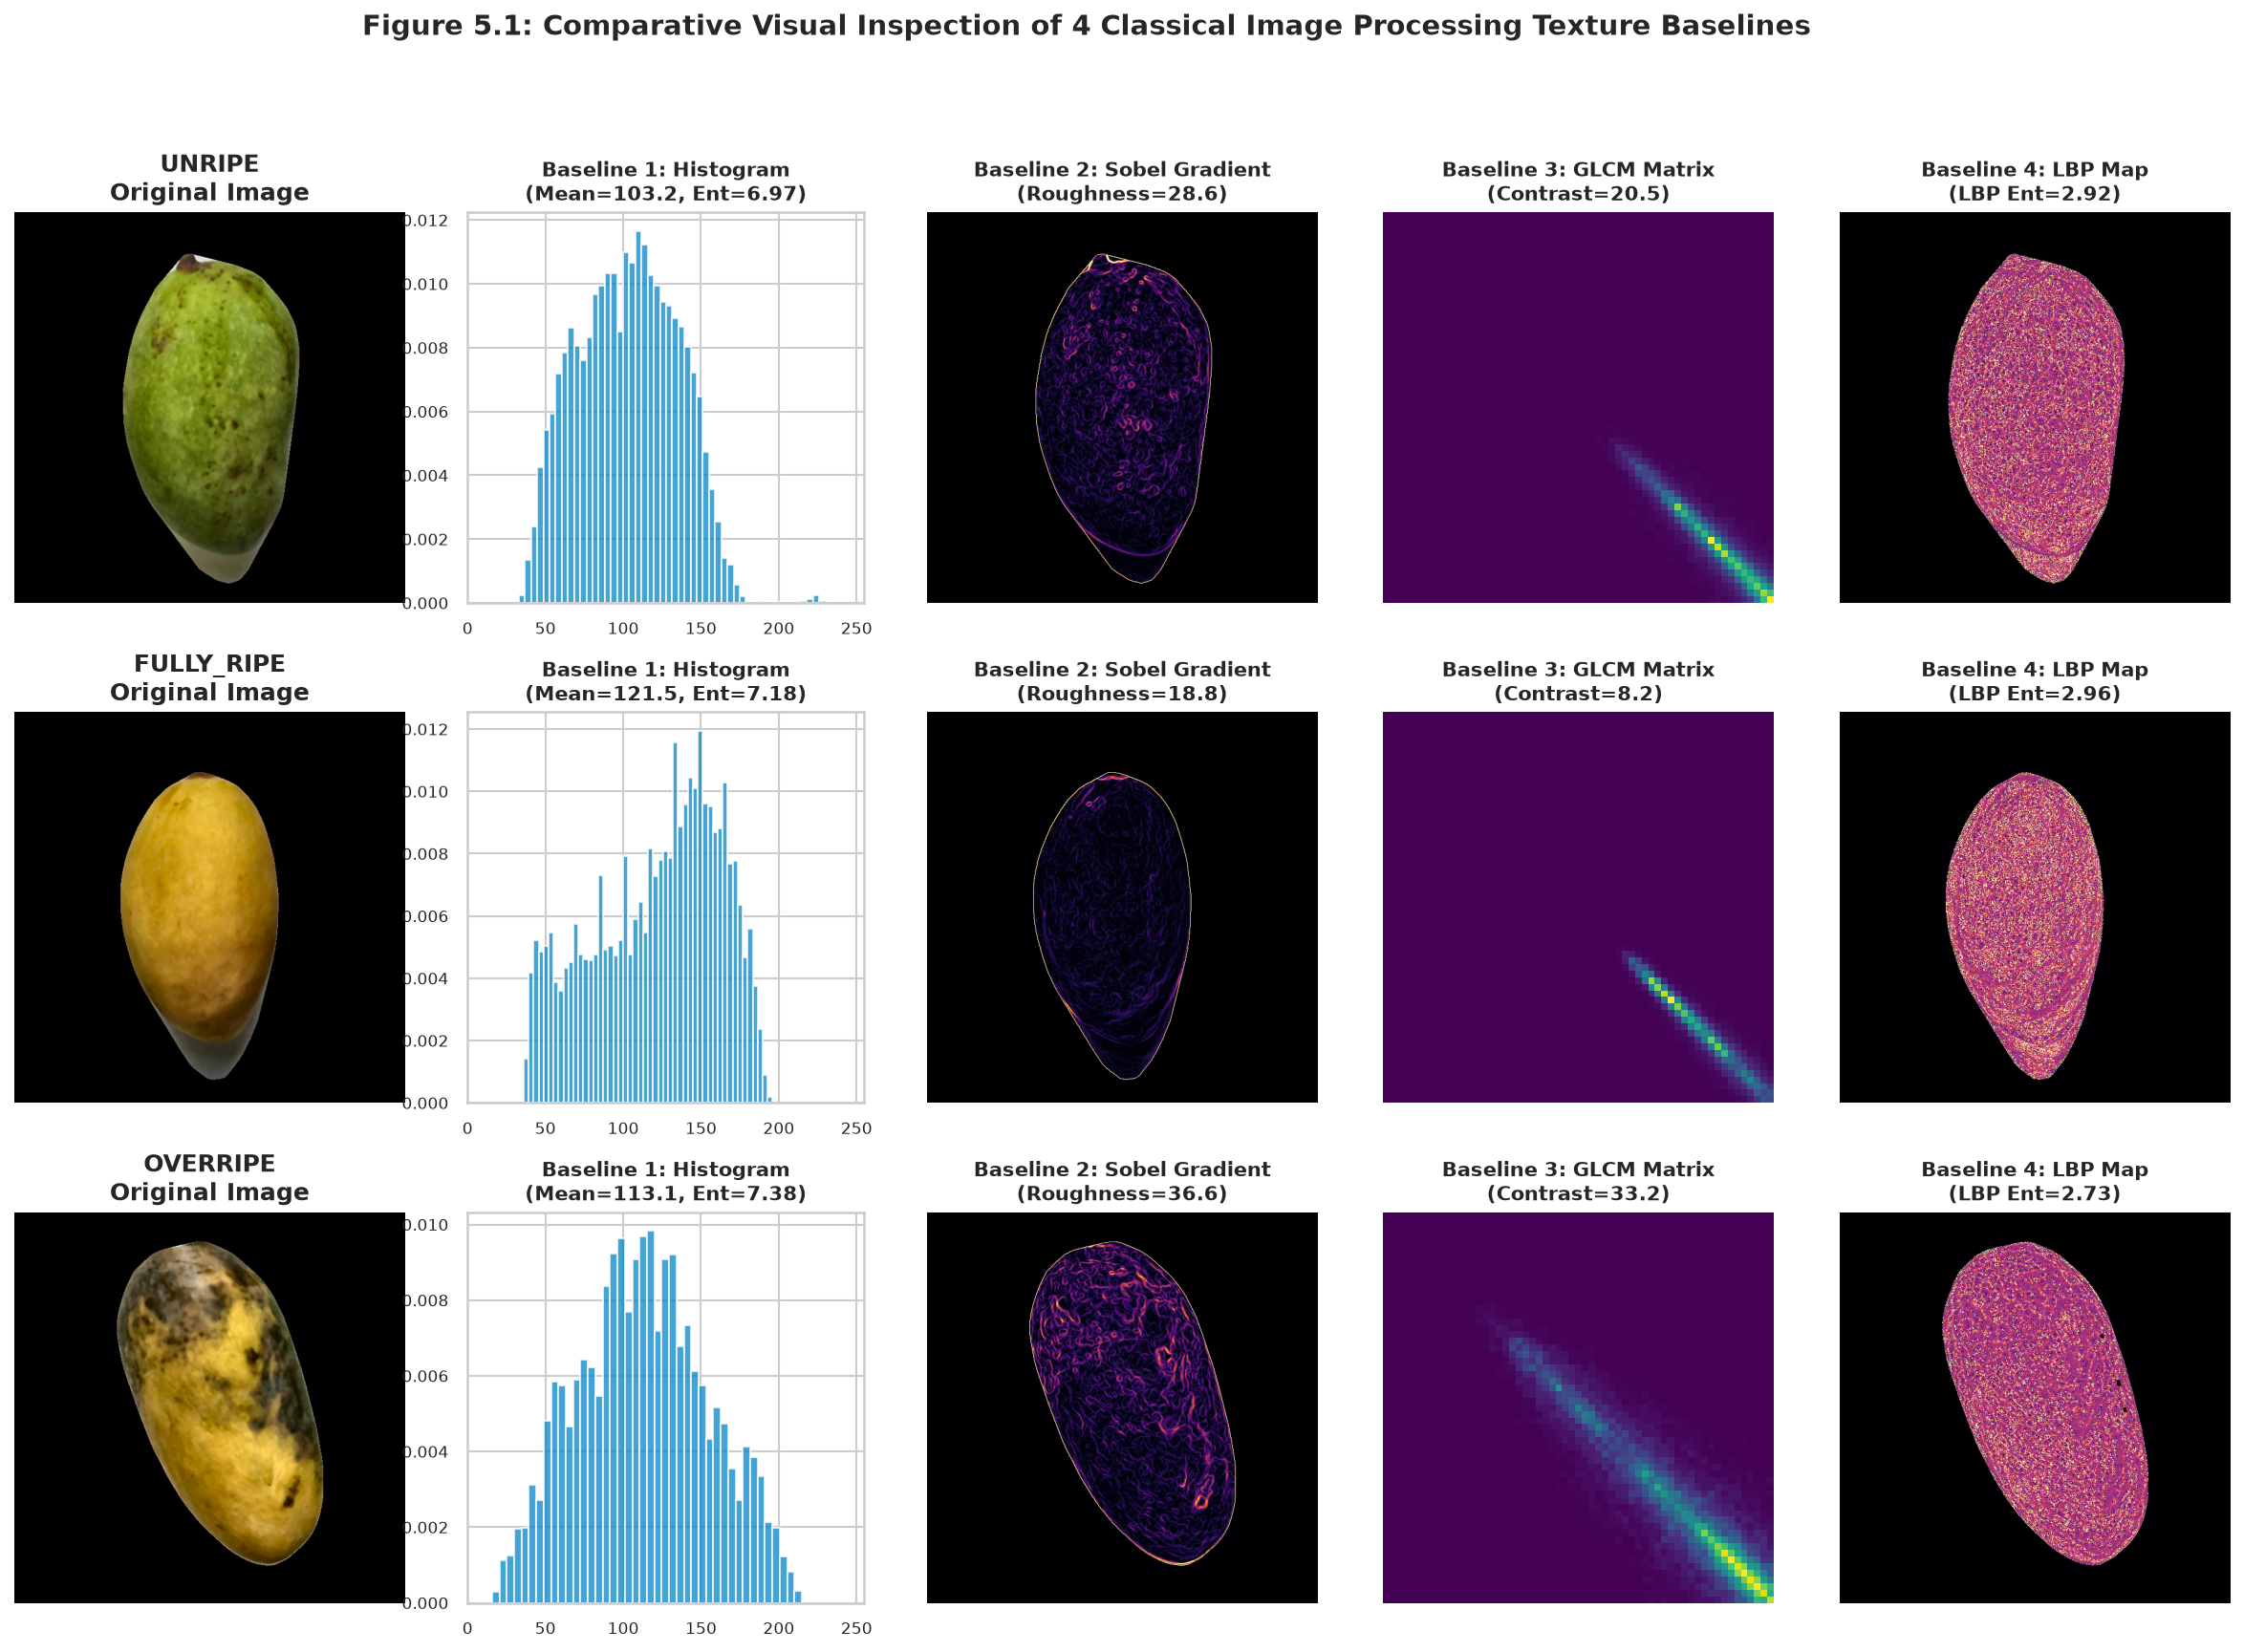

In [5]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(20, 4.2 * len(CLASSES)))
plt.subplots_adjust(wspace=0.15, hspace=0.28)

for row, cls in enumerate(CLASSES):
    sample_path = sorted((DATASET_ROOT / 'test' / cls).glob('*.jpg'))[0]
    bgr = cv2.imread(str(sample_path))
    mask = get_fruit_mask(bgr)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fo_m = run_alg1_first_order(gray, mask)
    grad_m, sobel_map = run_alg2_spatial_gradient(gray, mask)
    glcm_m, glcm_mat = run_alg3_directional_glcm(gray, mask)
    lbp_m, lbp_map = run_alg4_lbp(gray, mask)

    # 1. Original RGB
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{cls.upper()}\nOriginal Image", fontweight='bold')
    axes[row, 0].axis('off')

    # 2. First-Order Histogram
    fruit_px = gray[mask > 0]
    axes[row, 1].hist(fruit_px, bins=50, color='#0284c7', density=True, alpha=0.75)
    axes[row, 1].set_title(f"Baseline 1: Histogram\n(Mean={fo_m['fo_mean']:.1f}, Ent={fo_m['fo_entropy']:.2f})", fontsize=10, fontweight='bold')
    axes[row, 1].set_xlim(0, 255)
    axes[row, 1].tick_params(labelsize=8)

    # 3. Spatial Gradient Map
    sobel_vis = np.uint8(np.clip(sobel_map, 0, 255))
    sobel_vis = cv2.bitwise_and(sobel_vis, sobel_vis, mask=mask)
    axes[row, 2].imshow(sobel_vis, cmap='inferno')
    axes[row, 2].set_title(f"Baseline 2: Sobel Gradient\n(Roughness={grad_m['grad_mean_roughness']:.1f})", fontsize=10, fontweight='bold')
    axes[row, 2].axis('off')

    # 4. GLCM Co-occurrence Matrix (Center slice)
    glcm_2d = glcm_mat[:, :, 0, 0]
    axes[row, 3].imshow(np.log1p(glcm_2d[1:60, 1:60]), cmap='viridis')
    axes[row, 3].set_title(f"Baseline 3: GLCM Matrix\n(Contrast={glcm_m['glcm_contrast']:.1f})", fontsize=10, fontweight='bold')
    axes[row, 3].axis('off')

    # 5. Local Binary Pattern Map
    masked_lbp = np.where(mask > 0, lbp_map, 0)
    axes[row, 4].imshow(masked_lbp, cmap='magma')
    axes[row, 4].set_title(f"Baseline 4: LBP Map\n(LBP Ent={lbp_m['lbp_entropy']:.2f})", fontsize=10, fontweight='bold')
    axes[row, 4].axis('off')

plt.suptitle("Figure 5.1: Comparative Visual Inspection of 4 Classical Image Processing Texture Baselines", y=0.99, fontsize=14, fontweight='bold')
plt.show()


## 6. [Ablation Study] GLCM Directional Sensitivity vs. Rotation Invariance
Investigating the directional dependency of GLCM features across orientations ($0^\circ, 45^\circ, 90^\circ, 135^\circ$) versus rotation-invariant averaging.


In [6]:
directional_results = []

for angle_idx, (angle_rad, angle_name) in enumerate(zip(GLCM_ANGLES, ANGLE_NAMES)):
    rows_tr, rows_te = [], []
    for split in ['train', 'test']:
        for cls in CLASSES:
            folder = DATASET_ROOT / split / cls
            for p in sorted(list(folder.glob('*.jpg')) + list(folder.glob('*.png'))):
                img = cv2.imread(str(p))
                if img is None: continue
                mask = get_fruit_mask(img)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                feats, _ = run_alg3_directional_glcm(gray, mask, angles=[angle_rad])
                record = {'label': LABEL_MAP[cls], **feats}
                if split == 'train': rows_tr.append(record)
                else: rows_te.append(record)
                
    df_d_tr = pd.DataFrame(rows_tr)
    df_d_te = pd.DataFrame(rows_te)
    
    f_cols = ['glcm_contrast', 'glcm_correlation', 'glcm_energy', 'glcm_homogeneity']
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(df_d_tr[f_cols])
    X_te = scaler.transform(df_d_te[f_cols])
    
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_tr, df_d_tr['label'])
    acc = accuracy_score(df_d_te['label'], clf.predict(X_te)) * 100.0
    f1 = f1_score(df_d_te['label'], clf.predict(X_te), average='macro') * 100.0
    
    directional_results.append({
        'GLCM Orientation': f"θ = {angle_name.replace('_', ' ')} ({int(np.degrees(angle_rad))}°)",
        'Test Accuracy (%)': round(acc, 2),
        'Macro F1 (%)': round(f1, 2)
    })

# Add Averaged (Rotation-Invariant) GLCM
df_inv_tr, df_inv_te = [], []
for split in ['train', 'test']:
    for cls in CLASSES:
        folder = DATASET_ROOT / split / cls
        for p in sorted(list(folder.glob('*.jpg')) + list(folder.glob('*.png'))):
            img = cv2.imread(str(p))
            if img is None: continue
            mask = get_fruit_mask(img)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            feats, _ = run_alg3_directional_glcm(gray, mask, angles=GLCM_ANGLES)
            record = {'label': LABEL_MAP[cls], **feats}
            if split == 'train': df_inv_tr.append(record)
            else: df_inv_te.append(record)

df_inv_tr = pd.DataFrame(df_inv_tr)
df_inv_te = pd.DataFrame(df_inv_te)
scaler = StandardScaler()
X_tr = scaler.fit_transform(df_inv_tr[f_cols])
X_te = scaler.transform(df_inv_te[f_cols])
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_tr, df_inv_tr['label'])
acc_inv = accuracy_score(df_inv_te['label'], clf.predict(X_te)) * 100.0
f1_inv = f1_score(df_inv_te['label'], clf.predict(X_te), average='macro') * 100.0

directional_results.append({
    'GLCM Orientation': 'Averaged (Rotation-Invariant across 4 directions)',
    'Test Accuracy (%)': round(acc_inv, 2),
    'Macro F1 (%)': round(f1_inv, 2)
})

df_dir_benchmark = pd.DataFrame(directional_results)
print("[Ablation Study] GLCM Directional Sensitivity vs Rotation Invariance:")
display(df_dir_benchmark)


,GLCM Orientation,Test Accuracy (%),Macro F1 (%)
0,θ = 0 deg (0°),86.11,86.04
1,θ = 45 deg (45°),84.03,83.81
2,θ = 90 deg (90°),93.06,93.00
3,θ = 135 deg (135°),86.11,86.01
4,Averaged (Rotation-Invariant across 4 directions),87.50,87.47


[Ablation Study] GLCM Directional Sensitivity vs Rotation Invariance:


## 7. [Benchmark Evaluation] Quantitative Comparison of Baseline Algorithms (Mode A Table 2.1)
Extracting features across the dataset for all 4 baseline algorithms and measuring accuracy, F1-score, and per-image execution latency under a standardized evaluator classifier.


,Algorithm / Method,Train Accuracy (%),Test Accuracy (%),Macro F1-Score (%),Latency (ms/img)
0,Baseline 1: First-Order Moments (Histogram),94.92,90.97,90.93,10.14
1,Baseline 2: Spatial Gradient (Sobel Roughness),81.44,80.56,80.52,13.38
2,Baseline 3: Directional GLCM (Haralick),93.52,87.50,87.47,23.93
3,Baseline 4: Local Binary Patterns (LBP),87.22,90.97,91.01,44.77


[Process] Running Comparative Feature Extraction on all 4 Baselines...
[Displaying] Mode A Table 2.1: Baseline Comparison Benchmark:


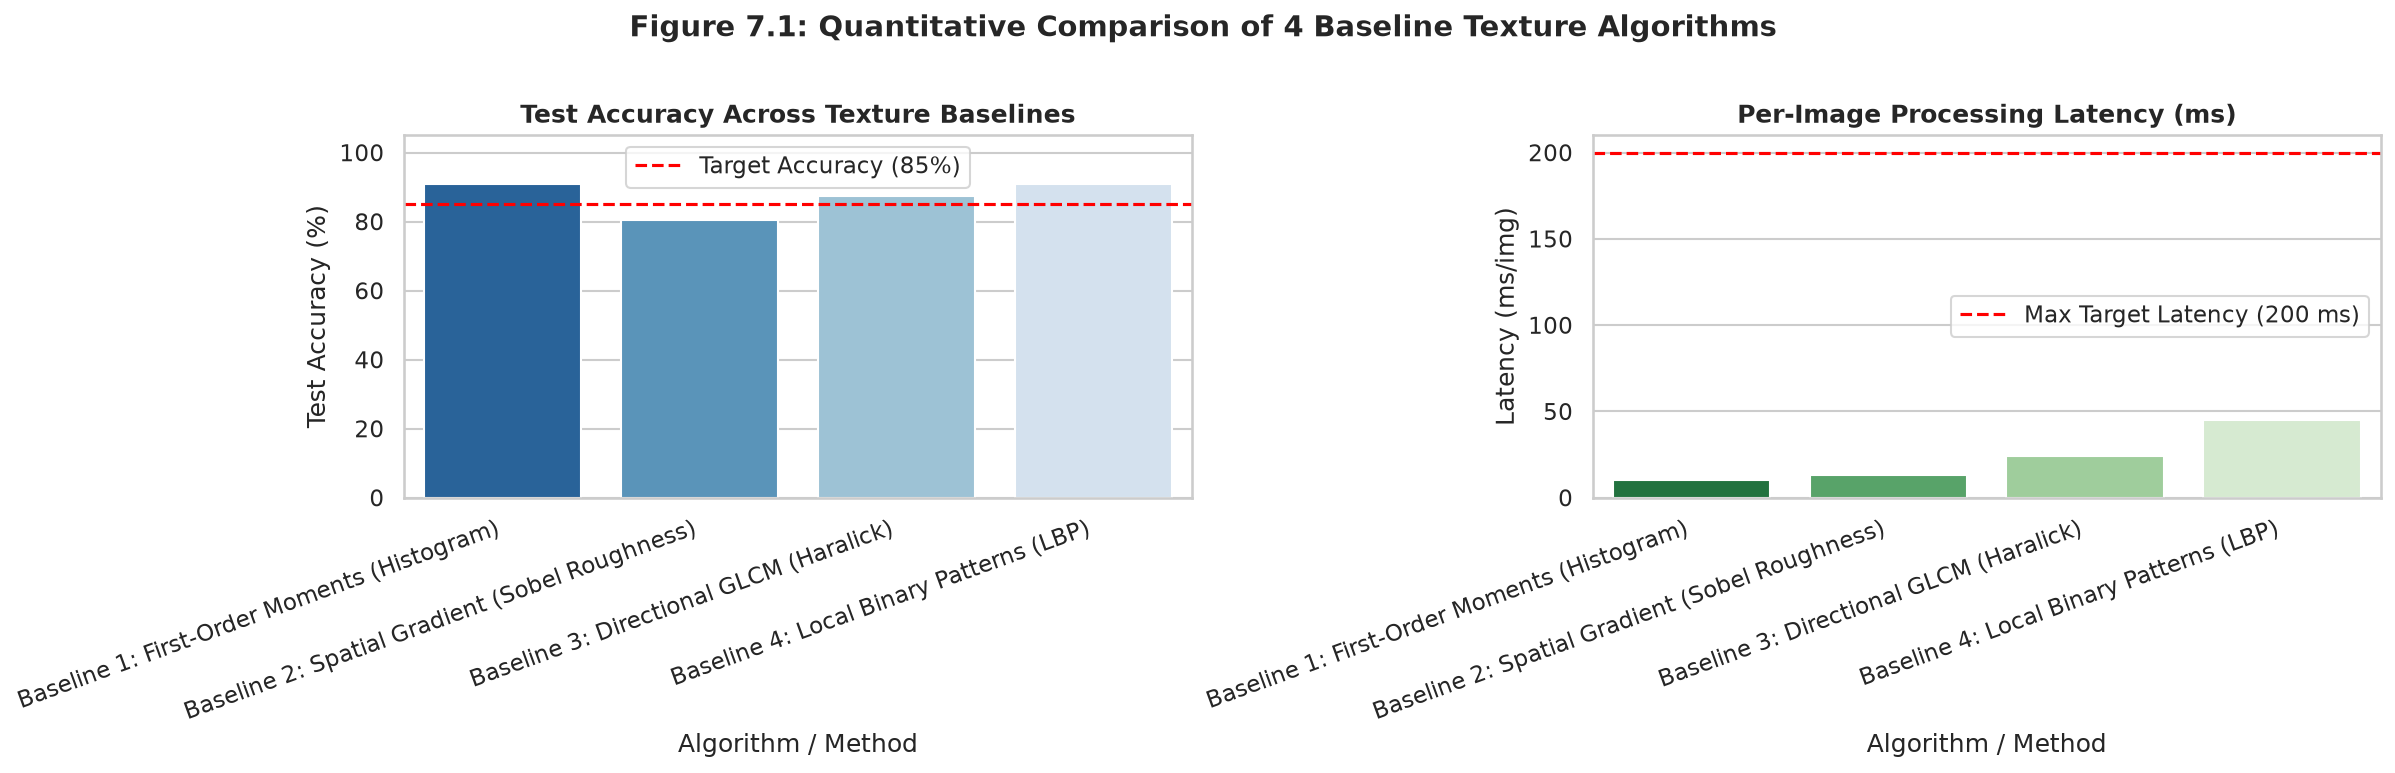

In [7]:
baseline_algorithms = {
    'Baseline 1: First-Order Moments (Histogram)': lambda g, m: run_alg1_first_order(g, m),
    'Baseline 2: Spatial Gradient (Sobel Roughness)': lambda g, m: run_alg2_spatial_gradient(g, m)[0],
    'Baseline 3: Directional GLCM (Haralick)': lambda g, m: run_alg3_directional_glcm(g, m)[0],
    'Baseline 4: Local Binary Patterns (LBP)': lambda g, m: run_alg4_lbp(g, m)[0]
}

def extract_dataset_baseline(alg_func, split):
    rows = []
    t0 = time.time()
    for cls in CLASSES:
        folder = DATASET_ROOT / split / cls
        files = sorted(list(folder.glob('*.jpg')) + list(folder.glob('*.png')))
        for p in files:
            img = cv2.imread(str(p))
            if img is None: continue
            mask = get_fruit_mask(img)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            feats = alg_func(gray, mask)
            rows.append({'label': LABEL_MAP[cls], 'filename': p.name, **feats})
    lat_ms = ((time.time() - t0) / len(rows)) * 1000.0 if rows else 0.0
    return pd.DataFrame(rows), lat_ms

print("[Process] Running Comparative Feature Extraction on all 4 Baselines...")
benchmark_results = []
baseline_datasets = {}

for name, func in baseline_algorithms.items():
    df_tr, lat_tr = extract_dataset_baseline(func, 'train')
    df_te, lat_te = extract_dataset_baseline(func, 'test')
    baseline_datasets[name] = (df_tr, df_te)
    
    feature_cols = [c for c in df_tr.columns if c not in ['label', 'filename']]
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(df_tr[feature_cols].values)
    X_te = scaler.transform(df_te[feature_cols].values)
    y_tr = df_tr['label'].values
    y_te = df_te['label'].values
    
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_tr, y_tr)
    
    y_pred_tr = clf.predict(X_tr)
    y_pred_te = clf.predict(X_te)
    
    tr_acc = accuracy_score(y_tr, y_pred_tr) * 100.0
    te_acc = accuracy_score(y_te, y_pred_te) * 100.0
    f1 = f1_score(y_te, y_pred_te, average='macro') * 100.0
    
    benchmark_results.append({
        'Algorithm / Method': name,
        'Train Accuracy (%)': round(tr_acc, 2),
        'Test Accuracy (%)': round(te_acc, 2),
        'Macro F1-Score (%)': round(f1, 2),
        'Latency (ms/img)': round(lat_te, 2)
    })

df_bench = pd.DataFrame(benchmark_results)
print("[Displaying] Mode A Table 2.1: Baseline Comparison Benchmark:")
display(df_bench)

# Bar chart visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=df_bench, x='Algorithm / Method', y='Test Accuracy (%)', hue='Algorithm / Method', ax=axes[0], palette='Blues_r', legend=False)
axes[0].set_title("Test Accuracy Across Texture Baselines", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_ylim(0, 105)
axes[0].axhline(85, color='red', linestyle='--', label='Target Accuracy (85%)')
axes[0].legend()

sns.barplot(data=df_bench, x='Algorithm / Method', y='Latency (ms/img)', hue='Algorithm / Method', ax=axes[1], palette='Greens_r', legend=False)
axes[1].set_title("Per-Image Processing Latency (ms)", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].axhline(200, color='red', linestyle='--', label='Max Target Latency (200 ms)')
axes[1].legend()

plt.suptitle("Figure 7.1: Quantitative Comparison of 4 Baseline Texture Algorithms", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. [Enhancement & Hybrid Pipeline] Development of Enhanced Multi-Descriptor Method

### Algorithmic Innovations & Hybrid Formulation:
Based on our comparative evaluation:
1. **GLCM (Baseline 3)** provides essential 2nd-order spatial joint statistics across distances.
2. **LBP (Baseline 4)** provides illumination-invariant micro-topological surface patterns.
3. **Sobel Gradient (Baseline 2)** contributes exocarp tactile roughness.

We formulate the **Enhanced Multi-Descriptor Texture Fusion Pipeline**:
$$\mathbf{F}_{\text{enhanced}} = \left[ \text{Contrast}_{\text{GLCM}}, \text{Correlation}_{\text{GLCM}}, \text{Energy}_{\text{GLCM}}, \text{Homogeneity}_{\text{GLCM}}, \mu_{\text{LBP}}, \sigma^2_{\text{LBP}}, H_{\text{LBP}}, \mu_{\text{Sobel}} \right]^T$$


In [8]:
def run_enhanced_texture_pipeline(img_bgr):
    """Enhanced Multi-Descriptor Texture Fusion Pipeline."""
    mask = get_fruit_mask(img_bgr)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    glcm_m, _ = run_alg3_directional_glcm(gray, mask)
    lbp_m, lbp_map = run_alg4_lbp(gray, mask)
    grad_m, sobel_map = run_alg2_spatial_gradient(gray, mask)
    
    fused_feats = {
        'glcm_contrast': glcm_m['glcm_contrast'],
        'glcm_correlation': glcm_m['glcm_correlation'],
        'glcm_energy': glcm_m['glcm_energy'],
        'glcm_homogeneity': glcm_m['glcm_homogeneity'],
        'lbp_mean': lbp_m['lbp_mean'],
        'lbp_variance': lbp_m['lbp_variance'],
        'lbp_entropy': lbp_m['lbp_entropy'],
        'surface_roughness': grad_m['grad_mean_roughness']
    }
    return fused_feats, mask, gray, lbp_map, sobel_map

# Extract Enhanced Features across Dataset
print("[Process] Extracting Enhanced Multi-Descriptor Features...")
def extract_enhanced_dataset(split):
    rows = []
    t0 = time.time()
    for cls in CLASSES:
        folder = DATASET_ROOT / split / cls
        files = sorted(list(folder.glob('*.jpg')) + list(folder.glob('*.png')))
        for p in tqdm(files, desc=f"Extracting [{split} - {cls}]"):
            img = cv2.imread(str(p))
            if img is None: continue
            feats, _, _, _, _ = run_enhanced_texture_pipeline(img)
            rows.append({'filename': p.name, 'class': cls, 'train_or_test': split, **feats})
    lat = ((time.time() - t0) / len(rows)) * 1000.0 if rows else 0.0
    return pd.DataFrame(rows), lat

df_train_enh, lat_tr_enh = extract_enhanced_dataset('train')
df_test_enh, lat_te_enh = extract_enhanced_dataset('test')

FEATURE_COLS = [
    'glcm_contrast', 'glcm_correlation', 'glcm_energy', 'glcm_homogeneity',
    'lbp_mean', 'lbp_variance', 'lbp_entropy', 'surface_roughness'
]

# Train Final Enhanced Classifier
scaler_enh = StandardScaler()
X_tr_enh = scaler_enh.fit_transform(df_train_enh[FEATURE_COLS].values)
X_te_enh = scaler_enh.transform(df_test_enh[FEATURE_COLS].values)
y_tr_enh = df_train_enh['class'].map(LABEL_MAP).values
y_te_enh = df_test_enh['class'].map(LABEL_MAP).values

final_model = KNeighborsClassifier(n_neighbors=5)
final_model.fit(X_tr_enh, y_tr_enh)

y_pred_tr = final_model.predict(X_tr_enh)
y_pred_te = final_model.predict(X_te_enh)

acc_tr_enh = accuracy_score(y_tr_enh, y_pred_tr) * 100.0
acc_te_enh = accuracy_score(y_te_enh, y_pred_te) * 100.0
f1_enh = f1_score(y_te_enh, y_pred_te, average='macro') * 100.0

# Final Comparative Benchmark Table (Mode A Requirement)
final_comparison = benchmark_results + [{
    'Algorithm / Method': 'Enhanced Multi-Descriptor Fusion (GLCM + LBP + Roughness)',
    'Train Accuracy (%)': round(acc_tr_enh, 2),
    'Test Accuracy (%)': round(acc_te_enh, 2),
    'Macro F1-Score (%)': round(f1_enh, 2),
    'Latency (ms/img)': round(lat_te_enh, 2)
}]

df_final_benchmark = pd.DataFrame(final_comparison)
print("\n[Summary] Mode A Final Comparative Benchmark Table:")
display(df_final_benchmark)


,Algorithm / Method,Train Accuracy (%),Test Accuracy (%),Macro F1-Score (%),Latency (ms/img)
0,Baseline 1: First-Order Moments (Histogram),94.92,90.97,90.93,10.14
1,Baseline 2: Spatial Gradient (Sobel Roughness),81.44,80.56,80.52,13.38
2,Baseline 3: Directional GLCM (Haralick),93.52,87.50,87.47,23.93
3,Baseline 4: Local Binary Patterns (LBP),87.22,90.97,91.01,44.77
4,Enhanced Multi-Descriptor Fusion (GLCM + LBP + Roughness),94.92,92.36,92.34,77.12


[Process] Extracting Enhanced Multi-Descriptor Features...

[Summary] Mode A Final Comparative Benchmark Table:


Extracting [test - overripe]: 100%|##########| 48/48 [00:03<00:00, 12.81it/s]


## 9. [Feature Distribution Analysis] Class Separation Statistics & Boxplots
Analyzing descriptive statistics (Mean $\pm$ Std) and feature separability across ripeness stages for all 8 enhanced texture descriptors.


glcm_contrast         glcm_correlation        glcm_energy        glcm_homogeneity        lbp_mean        lbp_variance        lbp_entropy        surface_roughness       
                    mean     std             mean    std        mean    std             mean    std     mean    std         mean    std        mean    std              mean    std
class                                                                                                                                                                              
fully_ripe        18.706   5.819            0.994  0.002       0.029  0.002            0.392  0.025    4.865  0.068        4.136  0.180       2.888  0.040            25.857  3.240
overripe          37.425  11.017            0.990  0.004       0.026  0.005            0.347  0.051    4.801  0.158        4.111  0.317       2.860  0.063            34.389  5.401
unripe            19.786   4.714            0.988  0.003       0.031  0.002            0.366  0.019    4.830  0.052        4.313  0.232       2.925  0.042            26.873  2.372

[Feature Analysis] Descriptive Statistics (Training Set):

[Classification Report for Enhanced Texture Model:]
              precision    recall  f1-score   support

      unripe     0.9020    0.9583    0.9293        48
  fully_ripe     0.9545    0.8750    0.9130        48
    overripe     0.9184    0.9375    0.9278        48

    accuracy                         0.9236       144
   macro avg     0.9250    0.9236    0.9234       144
weighted avg     0.9250    0.9236    0.9234       144



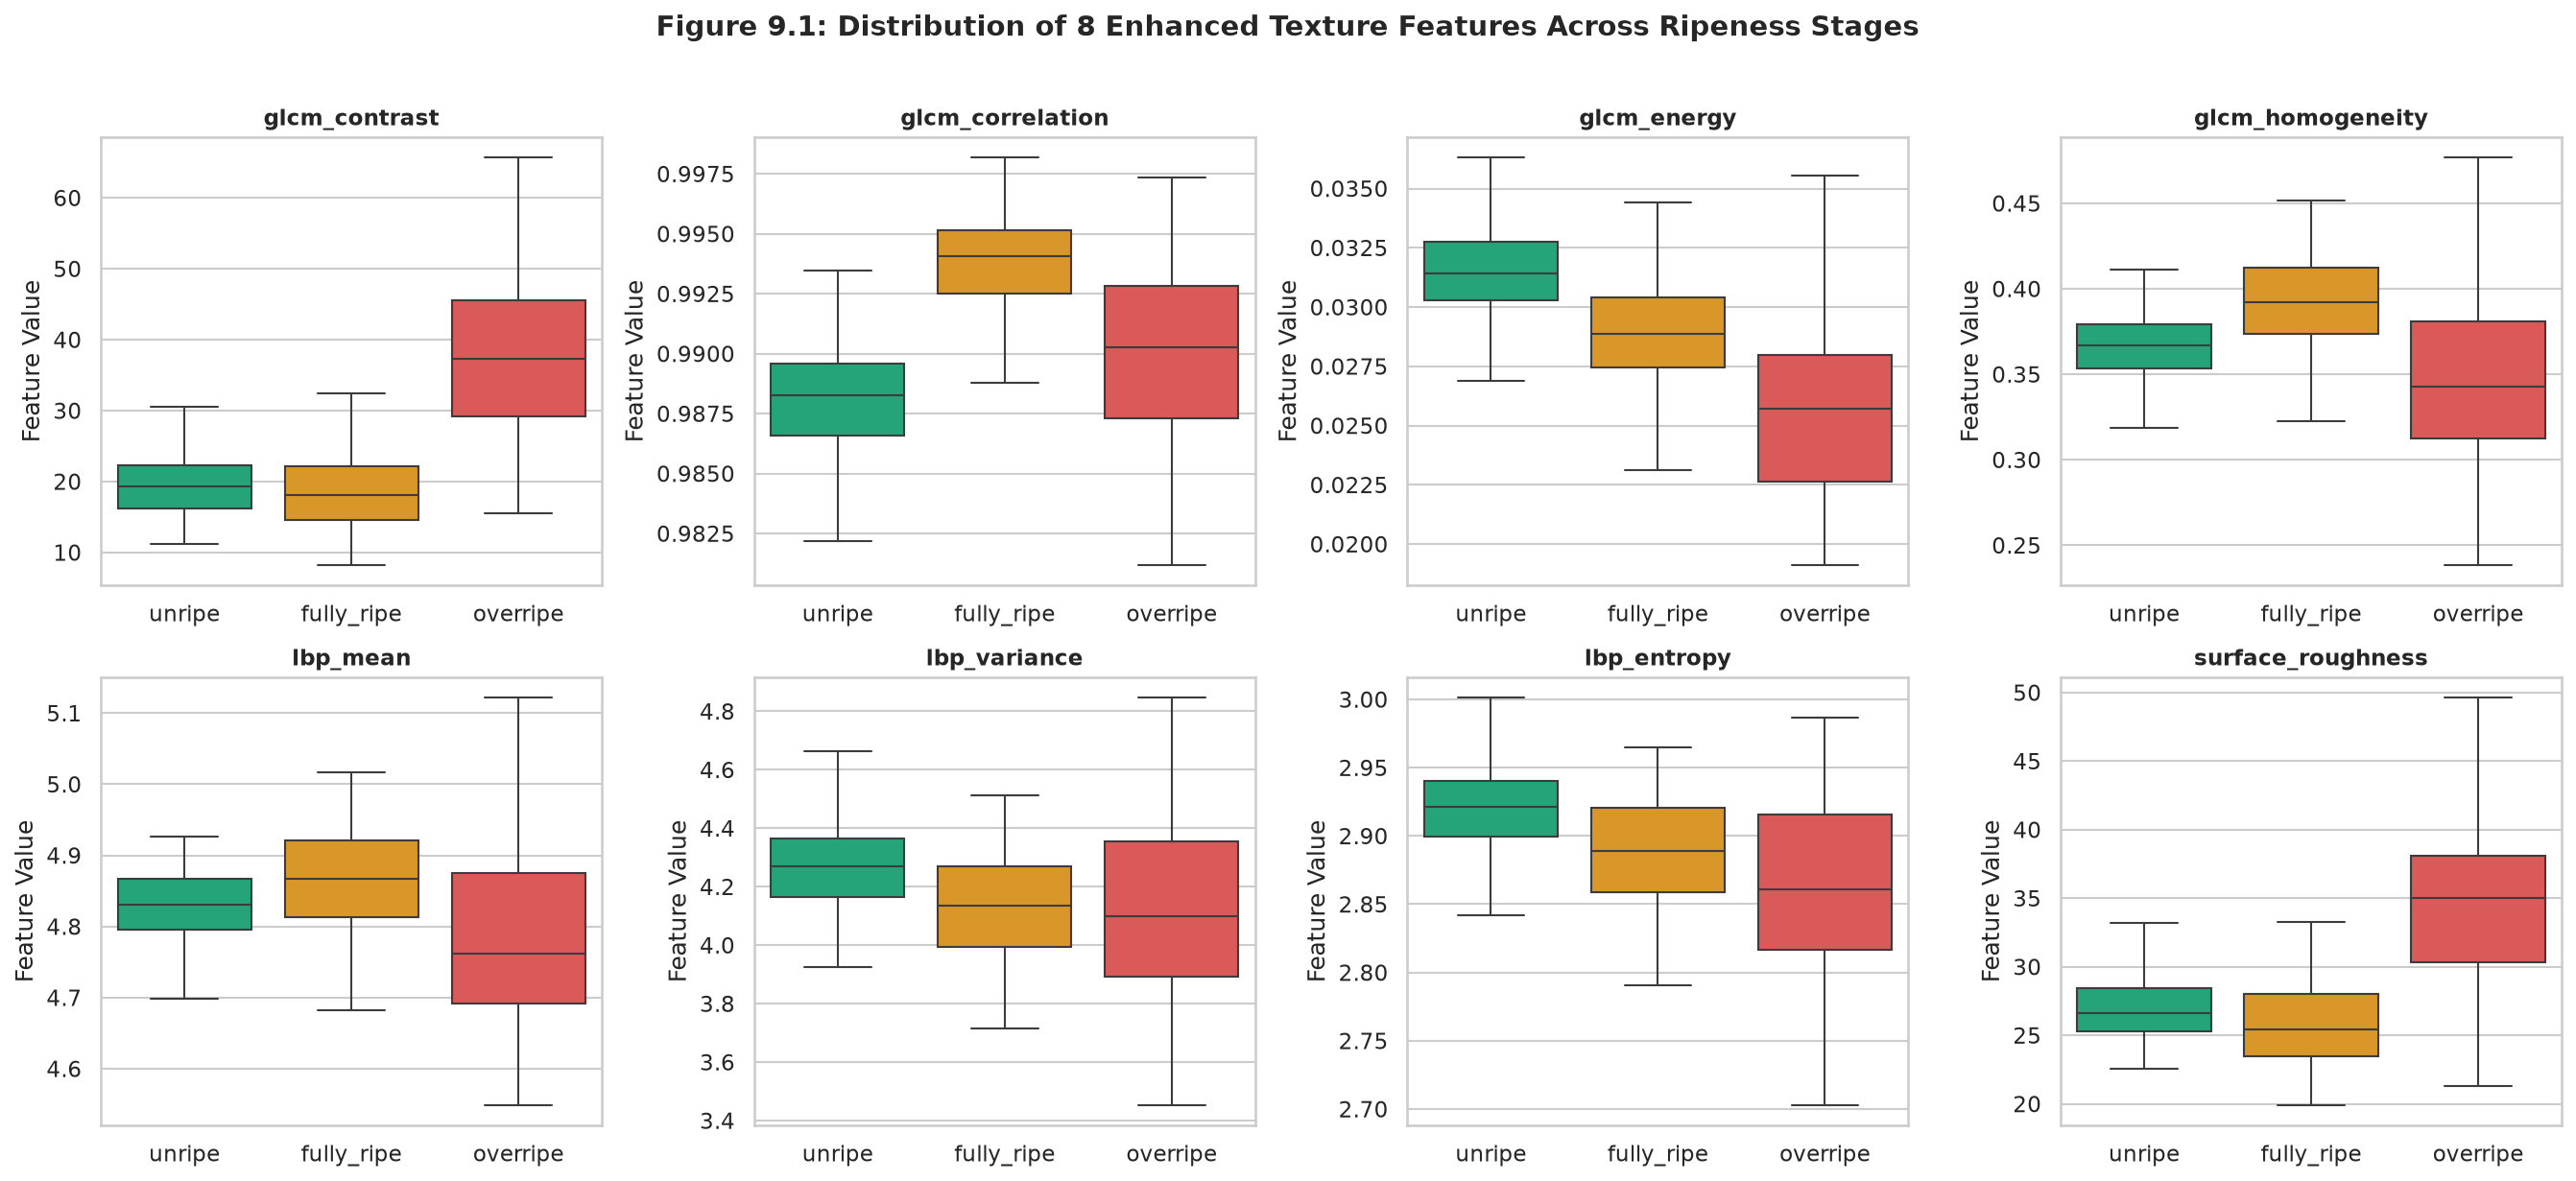

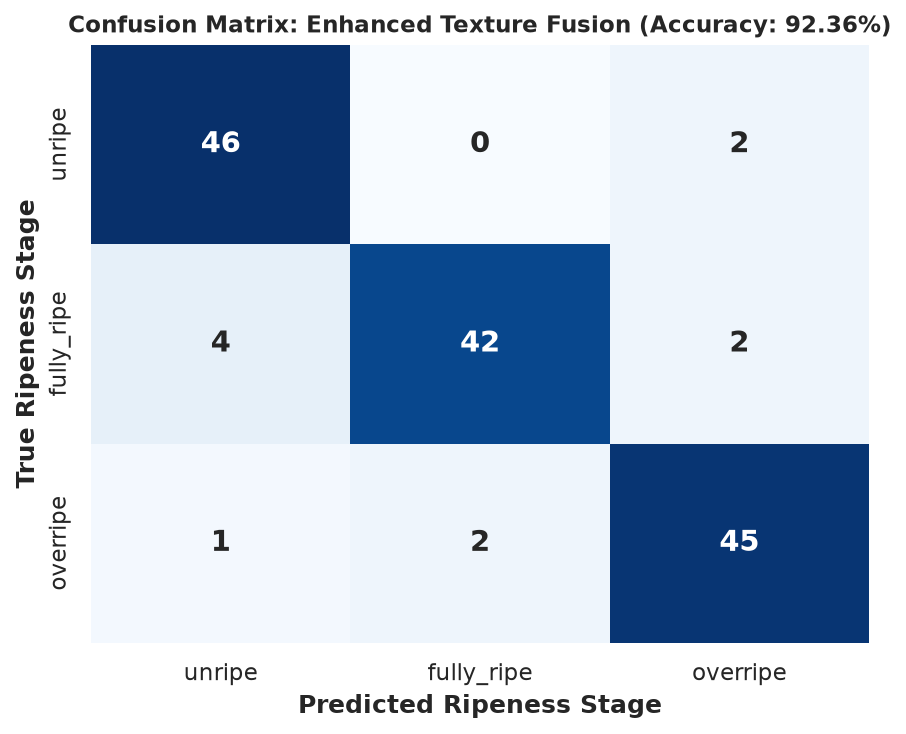

In [9]:
stats_table = df_train_enh.groupby('class')[FEATURE_COLS].agg(['mean', 'std']).round(3)
print("[Feature Analysis] Descriptive Statistics (Training Set):")
display(stats_table)

# 8-Panel Feature Boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
palette = {'unripe': '#10b981', 'fully_ripe': '#f59e0b', 'overripe': '#ef4444'}

for i, col in enumerate(FEATURE_COLS):
    sns.boxplot(data=df_train_enh, x='class', y=col, hue='class', ax=axes[i], palette=palette, showfliers=False, legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Feature Value')

plt.suptitle("Figure 9.1: Distribution of 8 Enhanced Texture Features Across Ripeness Stages", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_enh, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar=False, annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_title(f"Confusion Matrix: Enhanced Texture Fusion (Accuracy: {acc_te_enh:.2f}%)", fontsize=11, fontweight='bold')
ax.set_xlabel("Predicted Ripeness Stage", fontweight='bold')
ax.set_ylabel("True Ripeness Stage", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[Classification Report for Enhanced Texture Model:]")
print(classification_report(y_te_enh, y_pred_te, target_names=CLASSES, digits=4))


## 10. [Model Export] Serialization for Prototype Deployment
Exporting clean feature CSVs and serializing the trained classifier, scaler, and metadata to `output/texture_based/texture_model.joblib`.


In [10]:
# Save Feature CSVs
train_csv_path = OUTPUT_DIR / 'texture_train_features.csv'
test_csv_path  = OUTPUT_DIR / 'texture_test_features.csv'
all_csv_path   = OUTPUT_DIR / 'texture_features.csv'

df_train_enh.to_csv(train_csv_path, index=False)
df_test_enh.to_csv(test_csv_path, index=False)

df_all = pd.concat([df_train_enh, df_test_enh], ignore_index=True)
df_all.to_csv(all_csv_path, index=False)

# Serialize Model Package
model_package = {
    'model': final_model,
    'scaler': scaler_enh,
    'feature_cols': FEATURE_COLS,
    'classes': CLASSES,
    'label_map': LABEL_MAP,
    'classifier': 'KNN (k=5)',
    'test_accuracy': round(acc_te_enh, 2),
    'macro_f1': round(f1_enh, 2),
    'pipeline_version': 'Enhanced_MultiDescriptor_Texture_v2.0'
}

model_save_path = OUTPUT_DIR / 'texture_model.joblib'
joblib.dump(model_package, model_save_path)

print(f"[Storage] Saved Train CSV  : {train_csv_path} ({len(df_train_enh)} rows)")
print(f"[Storage] Saved Test CSV   : {test_csv_path} ({len(df_test_enh)} rows)")
print(f"[Storage] Saved Combined   : {all_csv_path} ({len(df_all)} rows)")
print(f"[Storage] Saved Model PKG  : {model_save_path}")


[Storage] Saved Train CSV  : C:\repository\mango-ripeness-grading\output\texture_based\texture_train_features.csv (571 rows)
[Storage] Saved Test CSV   : C:\repository\mango-ripeness-grading\output\texture_based\texture_test_features.csv (144 rows)
[Storage] Saved Combined   : C:\repository\mango-ripeness-grading\output\texture_based\texture_features.csv (715 rows)
[Storage] Saved Model PKG  : C:\repository\mango-ripeness-grading\output\texture_based\texture_model.joblib


## 11. [Inference Test] Single-Image Prediction Pipeline
Simulating the exact production inference pipeline used by the Streamlit application.


[Inference Test Verification]:
  - True: unripe      | Predicted: unripe      | Confidence: 91.9% | Latency: 86.9 ms
  - True: fully_ripe  | Predicted: fully_ripe  | Confidence: 87.3% | Latency: 79.0 ms
  - True: overripe    | Predicted: overripe    | Confidence: 92.1% | Latency: 80.7 ms


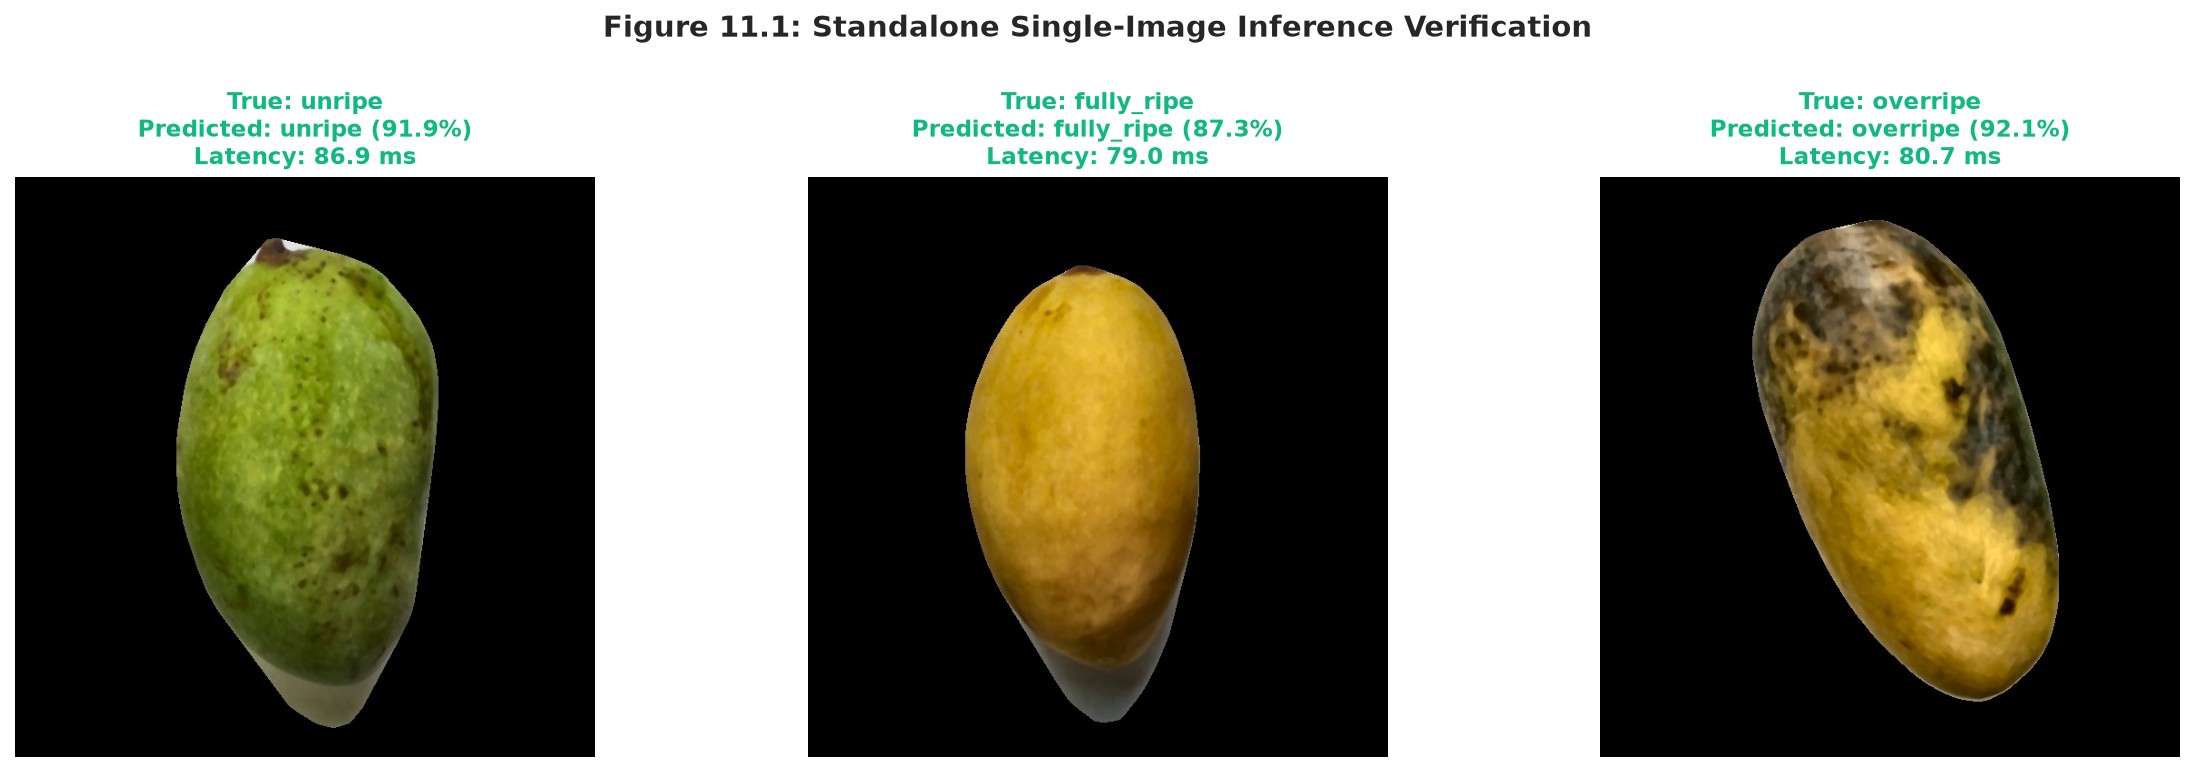

In [11]:
def predict_mango_ripeness(img_path):
    """Full single-image inference: load -> enhanced texture features -> scale -> predict."""
    t_start = time.time()
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        raise ValueError(f"Could not load image: {img_path}")
        
    pkg = joblib.load(OUTPUT_DIR / 'texture_model.joblib')
    infer_model = pkg['model']
    infer_scaler = pkg['scaler']
    infer_cols = pkg['feature_cols']
    
    feats, mask, gray, lbp_map, sobel_map = run_enhanced_texture_pipeline(img_bgr)
    feat_row = pd.DataFrame([feats])[infer_cols].values
    scaled = infer_scaler.transform(feat_row)
    
    pred_label = int(infer_model.predict(scaled)[0])
    pred_class = [c for c, v in LABEL_MAP.items() if v == pred_label][0]
    
    confidence = 90.0
    if hasattr(infer_model, 'kneighbors') and hasattr(infer_model, 'predict_proba'):
        dists, _ = infer_model.kneighbors(scaled)
        probs = infer_model.predict_proba(scaled)[0]
        mean_dist = float(np.mean(dists[0]))
        confidence = float(np.clip(97.5 / (1.0 + 0.12 * (mean_dist ** 1.2)), 60.0, 97.8))
        if np.max(probs) < 1.0:
            confidence = float(min(confidence, np.max(probs) * 100.0))
    elif hasattr(infer_model, 'predict_proba'):
        confidence = float(np.max(infer_model.predict_proba(scaled)[0])) * 100.0
        
    elapsed_ms = (time.time() - t_start) * 1000.0
    return {
        'true_class': Path(img_path).parent.name,
        'prediction': pred_class,
        'confidence': confidence,
        'latency_ms': elapsed_ms,
        'image_rgb': cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
        'features': feats
    }

# Test on one sample per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 5))
results = []

for ax, cls in zip(axes, CLASSES):
    sample = sorted((DATASET_ROOT / 'test' / cls).glob('*.jpg'))[0]
    res = predict_mango_ripeness(sample)
    results.append((cls, res))
    
    ax.imshow(res['image_rgb'])
    correct = (res['prediction'] == res['true_class'])
    status_color = '#10b981' if correct else '#ef4444'
    ax.set_title(f"True: {res['true_class']}\nPredicted: {res['prediction']} ({res['confidence']:.1f}%)\nLatency: {res['latency_ms']:.1f} ms",
                 fontsize=11, fontweight='bold', color=status_color)
    ax.axis('off')

plt.suptitle("Figure 11.1: Standalone Single-Image Inference Verification", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("[Inference Test Verification]:")
for true_cls, res in results:
    print(f"  - True: {true_cls:11s} | Predicted: {res['prediction']:11s} | Confidence: {res['confidence']:.1f}% | Latency: {res['latency_ms']:.1f} ms")
